# Week 10: K-Means Clustering, Elbow Method, Silhouette Score

and Distance Metrics

## 1. Notebook Setup
- Import libraries

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)

## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)
#drop CustomerID col (irrelevant)
customer_churn = customer_churn.drop('CustomerID', axis=1)
#use sample of dataset for quicker runtime
sample, _ = train_test_split(
    customer_churn,
    train_size = 0.3, #use 30% of dataset
    stratify = customer_churn['Churn'],
    random_state = 42
)

#preprocessing: remove target cols and scale features
target_col = "Churn"
def preprocess(df, target_col):
    X = pd.get_dummies(df.drop(target_col, axis=1), drop_first=True)
    y = df[target_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, y
X_cc, X_cc_scaled, y_cc = preprocess(sample, target_col)

### 2.2 Elbow Method

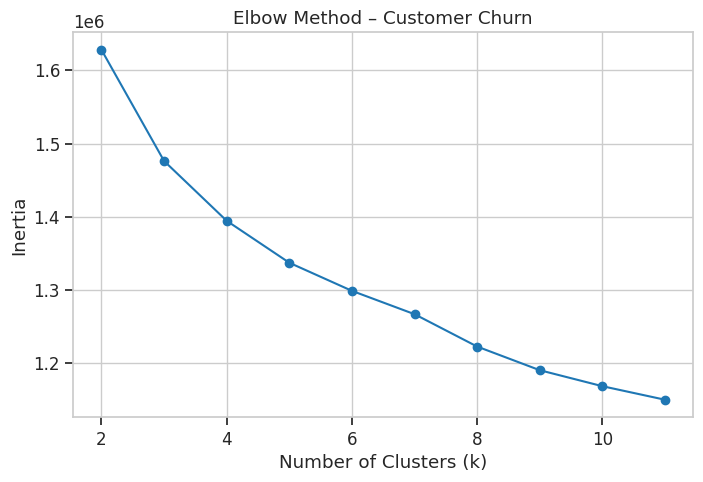

In [3]:
def plot_elbow(X_scaled, title):
    inertias = []
    K = range(2, 12)
    for k in K:
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
    #plot
    plt.figure(figsize=(8,5))
    plt.plot(K, inertias, marker='o')
    plt.title(f'Elbow Method – {title}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.show()
#run for dataset
plot_elbow(X_cc_scaled, "Customer Churn")

### 2.3: Silhouette Score Analysis

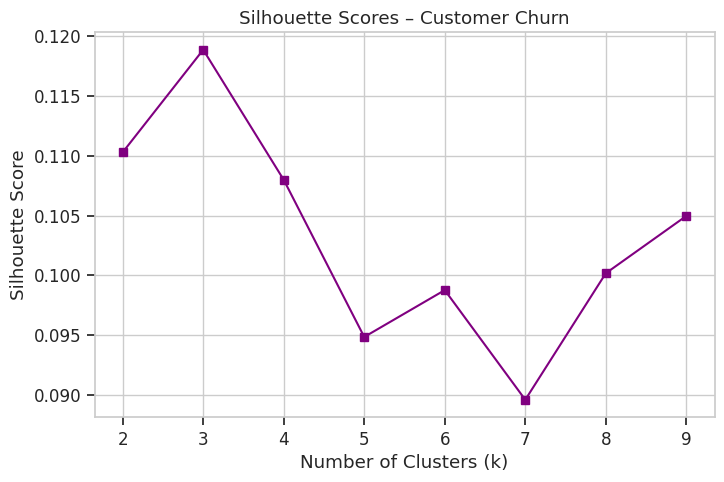

In [4]:
def evaluate_silhouette(X_scaled, title):
    K = range(2, 10)
    silhouette_vals = []
    for k in K:
        km = KMeans(n_clusters=k, random_state=42)
        labels = km.fit_predict(X_scaled)
        silhouette_vals.append(silhouette_score(X_scaled, labels))
    #plot
    plt.figure(figsize=(8,5))
    plt.plot(K, silhouette_vals, marker='s', color='purple')
    plt.title(f'Silhouette Scores – {title}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()
#run for dataset
evaluate_silhouette(X_cc_scaled, "Customer Churn")

### 2.4: PCA Variance Explained Plots

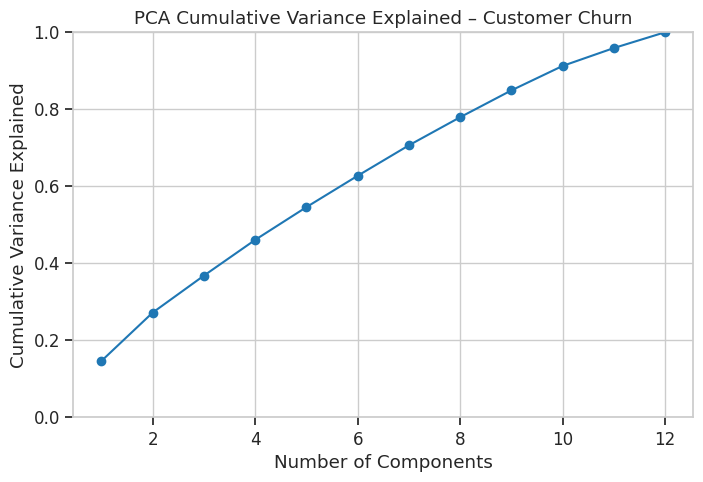

In [5]:
def plot_pca_variance(X_scaled, title):
    pca = PCA().fit(X_scaled)
    var_exp = pca.explained_variance_ratio_
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(var_exp)+1), np.cumsum(var_exp), marker='o')
    plt.title(f'PCA Cumulative Variance Explained – {title}')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()
#run for dataset
plot_pca_variance(X_cc_scaled, "Customer Churn")

### 2.5: K-Means Clustering and Visualization

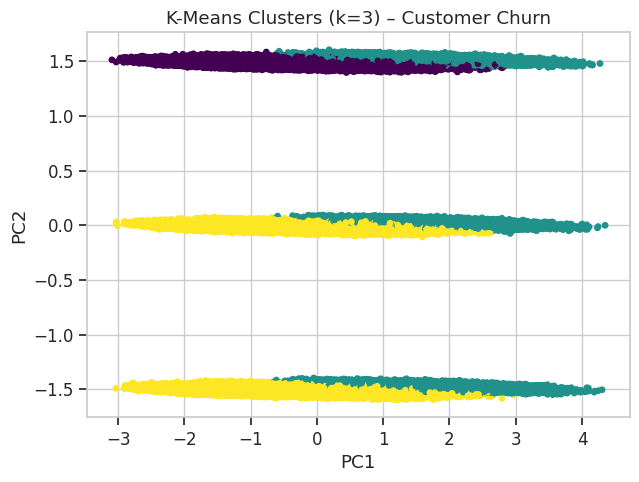

In [6]:
def kmeans_visualize(X_scaled, title, n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=42)
    labels = km.fit_predict(X_scaled)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    plt.figure(figsize=(7,5))
    plt.scatter(pcs[:,0], pcs[:,1], c=labels, cmap='viridis', s=15)
    plt.title(f'K-Means Clusters (k={n_clusters}) – {title}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

#visualize clusters using optimal k
kmeans_visualize(X_cc_scaled, "Customer Churn", 3)

#### Additional plots:
[insert any plots]

## 3. Dataset 2: digital_marketing_campaign

### 3.1: Data Overview & Preparation 

In [26]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
#drop null rows
digital_marketing.dropna(inplace=True)
#drop CustomerID col (irrelevant)
digital_marketing = digital_marketing.drop('CustomerID', axis=1)
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

X_dm, X_dm_scaled, y_dm = preprocess(digital_marketing, 'Conversion')

### 3.2 Elbow Method

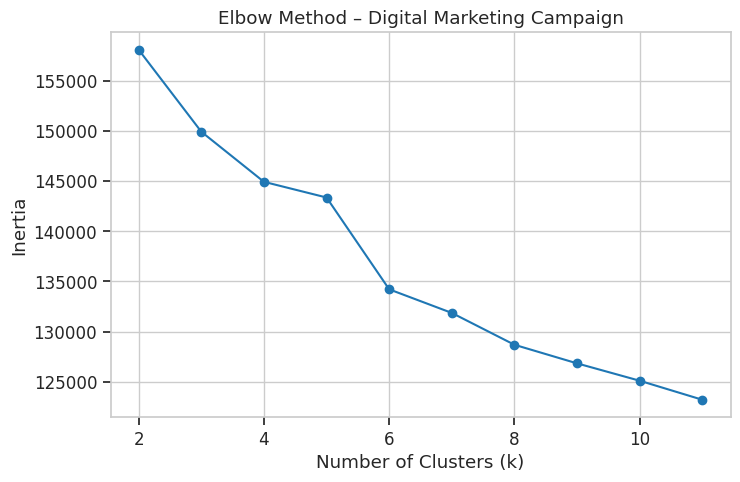

In [27]:
plot_elbow(X_dm_scaled, "Digital Marketing Campaign")

### 3.3: Silhouette Score Analysis

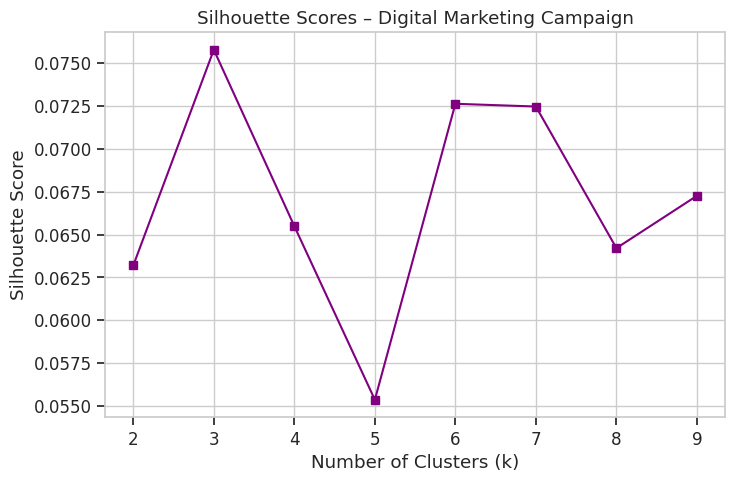

In [28]:
evaluate_silhouette(X_dm_scaled, "Digital Marketing Campaign")

### 3.4: PCA Variance Explained Plots

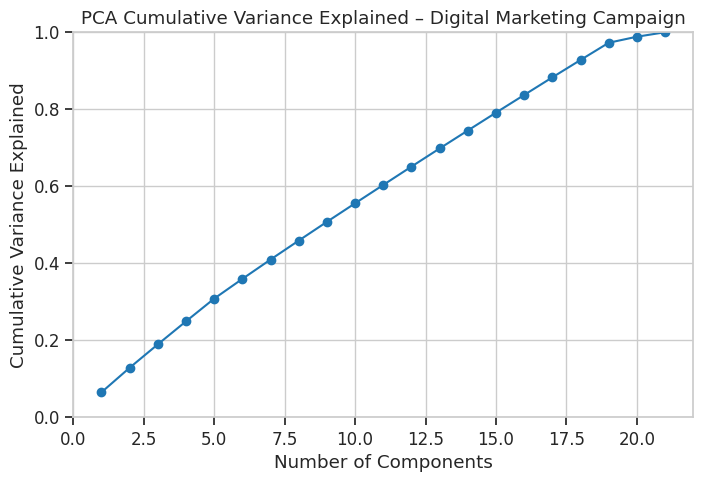

In [29]:
plot_pca_variance(X_dm_scaled, "Digital Marketing Campaign")

### 3.5: K-Means Clustering and Visualization

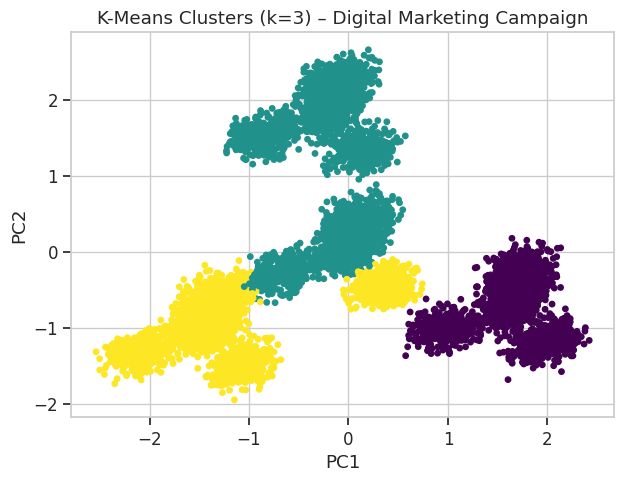

In [30]:
kmeans_visualize(X_dm_scaled, "Digital Marketing Campaign", 3)

## 4. Dataset 3: marketing_campaign

### 4.1: Data Overview & Preparation 

In [33]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
#drop null rows
marketing_campaign.dropna(inplace=True)
#drop CustomerID col (irrelevant)
marketing_campaign = marketing_campaign.drop('ID', axis=1)
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

X_mc, X_mc_scaled, y_mc = preprocess(marketing_campaign, 'Response')

### 4.2 Elbow Method

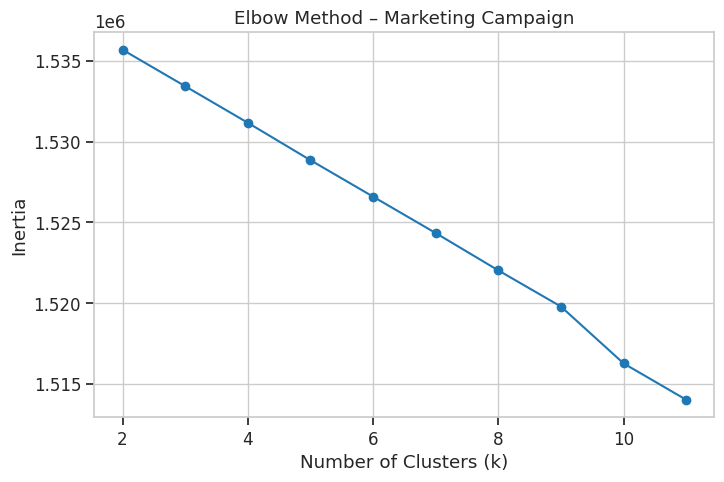

In [35]:
plot_elbow(X_mc_scaled, "Marketing Campaign")

### 4.3: Silhouette Score Analysis

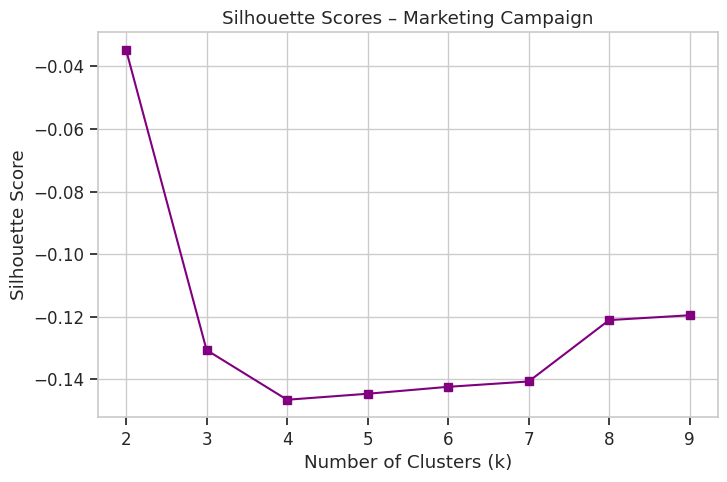

In [36]:
evaluate_silhouette(X_mc_scaled, "Marketing Campaign")

### 4.4: PCA Variance Explained Plots

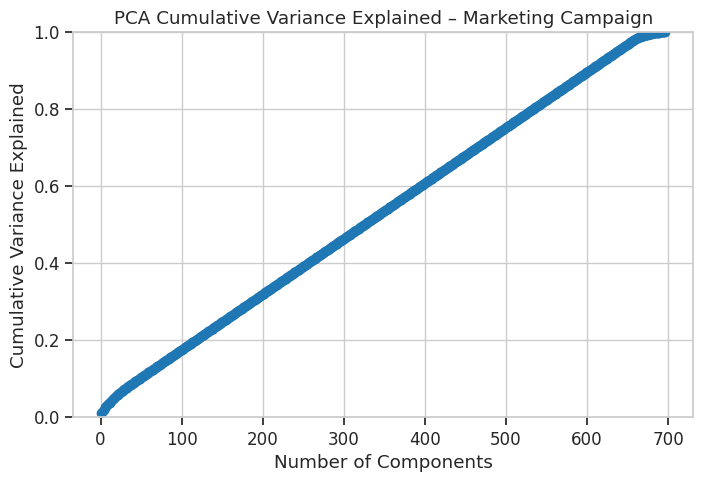

In [37]:
plot_pca_variance(X_mc_scaled, "Marketing Campaign")

### 4.5: K-Means Clustering and Visualization

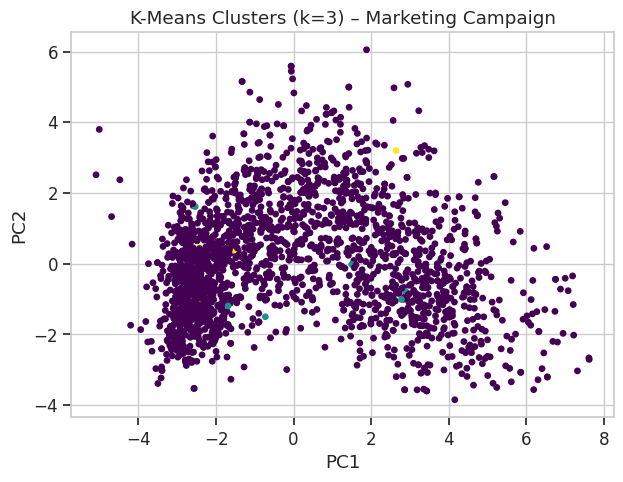

In [38]:
kmeans_visualize(X_mc_scaled, "Marketing Campaign", 3)